# Library Import

In [1]:
import gymnasium as gym
import torch
from torch import nn
import torch.optim as optim
from torch.distributions import Normal      # normal dist

import numpy as np
import matplotlib.pyplot as plt
from statistics import mean, stdev
import random

import re, os, json, time
from datetime import datetime
from collections import deque
from tqdm import tqdm

# --- import the custom-made TD3 algorithm
import sys
sys.path.insert(0,'..')
from algos import TD3

# Walker2D Training with TD3

In [2]:
model_registry = {
    'TD3_v0': {
        'actor_config': [256, 256],
        'critic_config': [256, 256]
    },
    'TD3_v1': {
        'actor_config': [256, 256, 256, 256],
        'critic_config': [256, 256, 256, 256]
    },
    'TD3_v2': {
        'actor_config': [400, 300],
        'critic_config': [400, 300]
    },
    'TD3_v3': {
        'actor_config': [512, 256],
        'critic_config': [512, 256]
    }
}

MODEL_NAME = 'TD3_v2'
ALPHA1 = 1e-3
ALPHA2 = 1e-3
BETA = 1e-3
GAMMA = 0.99
TAU_C = 5e-3
TAU_A = 5e-3
SIGMA = 0.3
CLIP = 0.5

BUFFER_SIZE = 200_000
BUFFER_INIT = 10_000
BATCH_SIZE = 256
  
UPDATE_FREQ = 2
UPDATE_STEP = 2
TRAIN_ITER = 1_000_000
TRAIN_CRIT = {"pass_limit": 5, "pass_score": 4_000, 'coeff_var_limit': 1.0}
RESULT_FOLDER = 'walker_TD3_results'
CUDA_ENABLED = True
EARLY_STOP = True

run_00006:  21%|████████▋                                | 213220/1000000 [12:02<4:36:27, 47.43it/s]

Good training at episode  867 with reward of 4151.385. Evaluation results μ=1790.391, σ=1588.137, CV= 0.887


run_00006:  23%|█████████▏                               | 225167/1000000 [12:52<5:53:10, 36.57it/s]

Good training at episode  890 with reward of 4074.582. Evaluation results μ=2474.437, σ=1219.476, CV= 0.493


run_00006:  24%|█████████▉                               | 243756/1000000 [14:11<7:14:47, 28.99it/s]

...

Good training at episode 1094 with reward of 4049.948. Evaluation results μ=4603.866, σ=80.754, CV= 0.018


run_00006:  39%|███████████████▉                         | 388783/1000000 [31:11<9:41:46, 17.51it/s]

Good training at episode 1097 with reward of 4378.445. Evaluation results μ=4529.012, σ=627.404, CV= 0.139


run_00006:  39%|████████████████▎                         | 389761/1000000 [31:19<49:02, 207.39it/s]

Good training at episode 1098 with reward of 4542.693. Evaluation results μ=4071.983, σ=898.877, CV= 0.221
Training done early at episode  1098. Best model saved at episode  1094 with evaluate reward (4071.983,898.877)
Best model episode 1094


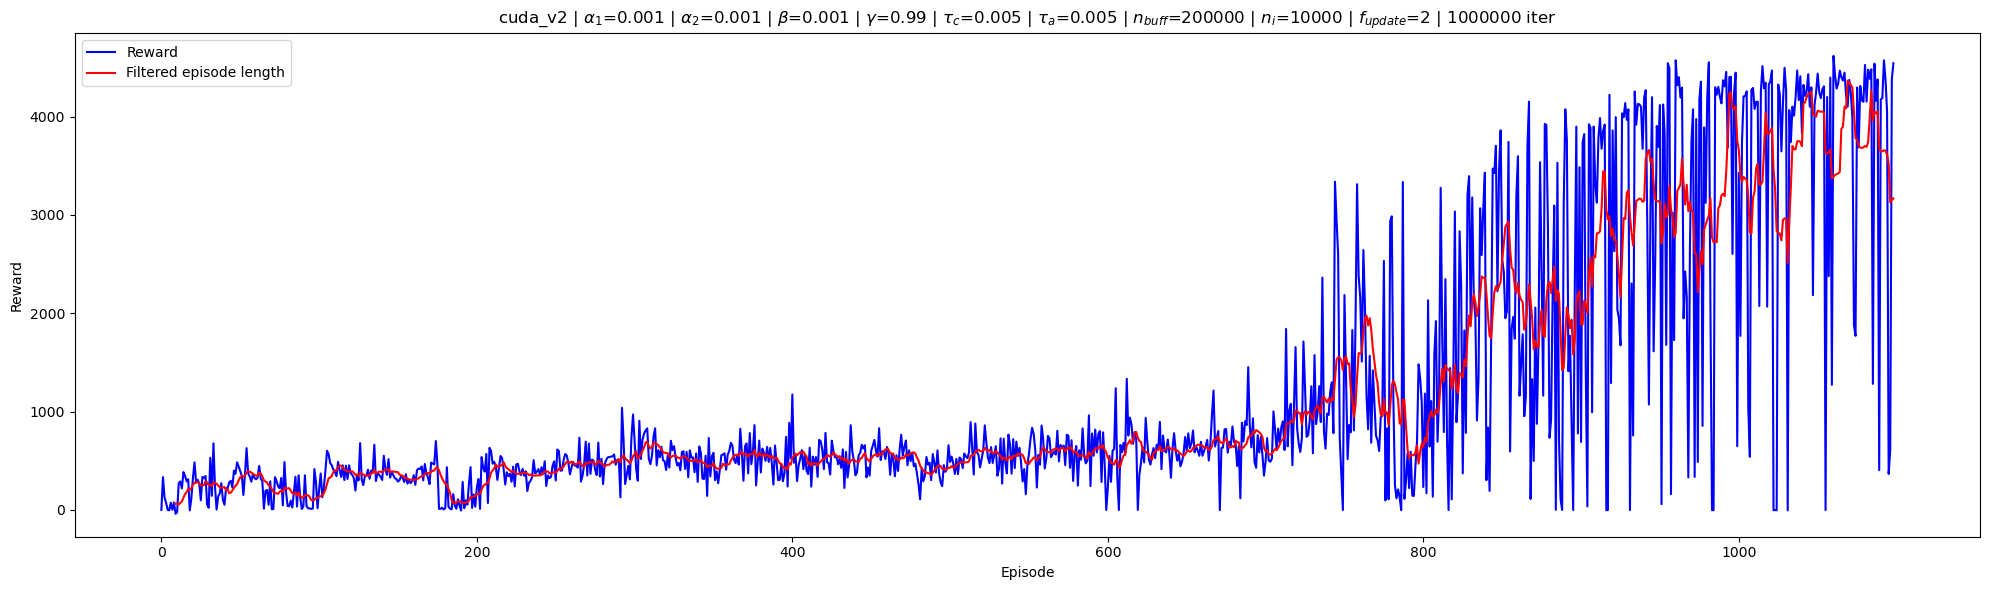

In [3]:
env = gym.make("Walker2d-v5",
               forward_reward_weight=1,     # weighting factor of the moving forward reward
               ctrl_cost_weight=1e-3,        # weighting factor of the large action penalty
               healthy_reward=1,
               terminate_when_unhealthy=True,
               healthy_z_range=(0.8,2),
               healthy_angle_range=(-1,1),
               reset_noise_scale=5e-3,       # scale of random pertubations in the initial state
               exclude_current_positions_from_observation=True
               )

for i in range(1):    
    seed = np.random.randint(1,100)
    TD3_experiment = TD3(model_name = MODEL_NAME, model_registry=model_registry, env=env,
                     alpha1=ALPHA1,alpha2=ALPHA2,beta=BETA,gamma=GAMMA,
                     tau_c=TAU_C,tau_a=TAU_A,sigma=SIGMA,clip=CLIP,
                     buffer_size=BUFFER_SIZE,buffer_init=BUFFER_INIT, batch_size=BATCH_SIZE, 
                     update_f=UPDATE_FREQ, update_step=UPDATE_STEP, iter=TRAIN_ITER,
                     seed=seed,
                     train_crit=TRAIN_CRIT,
                     result_folder=RESULT_FOLDER,
                     cuda_enabled=CUDA_ENABLED)                 
    TD3_experiment.train(early_stop=EARLY_STOP,verbose=True)